# OPSD gap on GSM8K

Tufa Labs showed that the **student vs self-teacher accuracy gap**, measured before
any training, linearly predicts how much OPSD post-training will help
([arXiv:2605.30070](https://arxiv.org/abs/2605.30070)). They measured it on code.

This notebook measures the same predictor on **grade-school math**, and adds two
contexts their setup does not have: a **misleading** one and a **corrupted** one.

No training here. What is measured is the predictor, not the final improvement.

**Runtime -> Change runtime type -> GPU (T4).**

## 1. Setup

In [1]:
!git clone -q https://github.com/kaj04/opsd-gap-gsm8k.git /content/opsd-gap-gsm8k || echo 'already cloned'
%cd /content/opsd-gap-gsm8k
!pip install -q vllm datasets
# pip warns about conflicts with Colab's preinstalled RAPIDS packages: harmless.
# Then Runtime -> Restart session, and run the next cell.

/content/opsd-gap-gsm8k
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [2]:
%cd /content/opsd-gap-gsm8k
!nvidia-smi --query-gpu=name,memory.total --format=csv

/content/opsd-gap-gsm8k
name, memory.total [MiB]
Tesla T4, 15360 MiB


## 2. The task

GSM8K: grade-school word problems with a human-written step-by-step solution and a
single numeric answer. The solutions are what every privileged context below is
built from.

In [3]:
from datasets import load_dataset
import numpy as np, textwrap

ds = load_dataset("openai/gsm8k", "main", split="test")
r = ds[3]
print(textwrap.fill(r["question"], 78))
print("\nreference solution:")
print(r["answer"])

sub = ds.select(range(300))
steps = [x["answer"].count("<<") for x in sub]
print("\nover the 300 problems used here: median %d calculation steps (min %d, max %d)" % (
    np.median(steps), min(steps), max(steps)))

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.31MB            

main/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

main/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  419kB            

main/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.
How many total meters does he run a week?

reference solution:
He sprints 3*3=<<3*3=9>>9 times
So he runs 9*60=<<9*60=540>>540 meters
#### 540

over the 300 problems used here: median 3 calculation steps (min 0, max 8)


## 3. The six conditions

The self-teacher is the same model, with extra text prepended. The teacher template
is copied verbatim from Tufa's `actor.yaml`; the contexts are ours.

| condition | what the teacher gets | expectation |
|---|---|---|
| `none` | nothing | the ruler: plain resampling |
| `gold_step1` | the first reasoning step | small help |
| `gold_steps` | every step but the last, so no final number | more help |
| `gt_solution` | the full solution, answer included | ceiling |
| `wrong_solution` | another problem's solution | should hurt |
| `corrupted_solution` | this problem's solution with the numbers shifted | should hurt, and is harder to notice |

The cell below prints one real example of each.

In [4]:
!python src/inspect_prompts.py --index 3

CONDITION: none
James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.  How many total meters does he run a week?

Solve the problem step by step. End your reply with the final numeric answer on its own line, in the form: #### <number>

>>> gold answer: 540.0 | the context points at: None

CONDITION: gold_step1
James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.  How many total meters does he run a week?

Solve the problem step by step. End your reply with the final numeric answer on its own line, in the form: #### <number>

Correct solution:

He sprints 3*3=9 times

Correctly solve the original question.

>>> gold answer: 540.0 | the context points at: None

CONDITION: gold_steps
James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.  How many total meters does he run a week?

Solve the problem step by step. End your reply with the final numeric answer on its own line, in the form: #### <number>

Correct soluti

## 4. Run

300 problems, 8 rollouts each, `enable_thinking=False`, temperature 0.7.

Following Tufa's gating, privileged context goes only to rollouts the student got
wrong, so the teacher is only run on those. Takes roughly 45 minutes on a T4.

In [5]:
!python src/run_eval.py --n-problems 300 --n-samples 8 --tag run

config.json: 100% 726/726 [00:00<00:00, 3.47MB/s]
tokenizer_config.json: 100% 9.73k/9.73k [00:00<00:00, 18.8MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 88.0MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 82.0MB/s]

tokenizer.json: downloading bytes:   0% 0.00/11.4M [00:00<?, ?B/s]
tokenizer.json: downloading bytes: 100% 3.40M/3.40M [00:01<00:00, 2.87MB/s,  330kB/s  ]
tokenizer.json: reconstructing file: 100% 11.4M/11.4M [00:01<00:00, 9.65MB/s, 1.11MB/s  ]
INFO 10-03 07:48:01 [api_utils.py:286] non-default args: {'max_model_len': 4096, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'Qwen/Qwen3-1.7B'}
INFO 10-03 07:48:22 [model.py:692] Resolved architecture: Qwen3ForCausalLM
WARNING 10-03 07:48:22 [model.py:2311] Your device 'Tesla T4' (with compute capability 7.5) doesn't support torch.bfloat16. Falling back to torch.float16 for compatibility.
WARNING 10-03 07:48:22 [model.py:2364] Casting torch.bfloat16 to torch.float16.
INFO 10-03 07:4

## 5. Results

Qwen/Qwen3-1.7B, 300 problems x 8 samples
student acc 0.807, 462 failed rollouts

condition                    recovery   vs none    95% CI on vs none  follows
none (resampling)               0.463    +0.000   [+0.000, +0.000]      -  
another problem's solution      0.491    +0.028   [-0.074, +0.130]    0.000
first step only                 0.610    +0.147   [+0.037, +0.255]      -  
all steps, no answer            0.713    +0.250   [+0.130, +0.361]      -  
corrupted solution              0.751    +0.288   [+0.177, +0.399]    0.087
full solution (ceiling)         0.926    +0.463   [+0.361, +0.565]    0.000

recovery = share of failed rollouts the self-teacher fixes
follows  = share where the model returned the number the context points at

wrote results/gaps.csv and figures/gaps.png


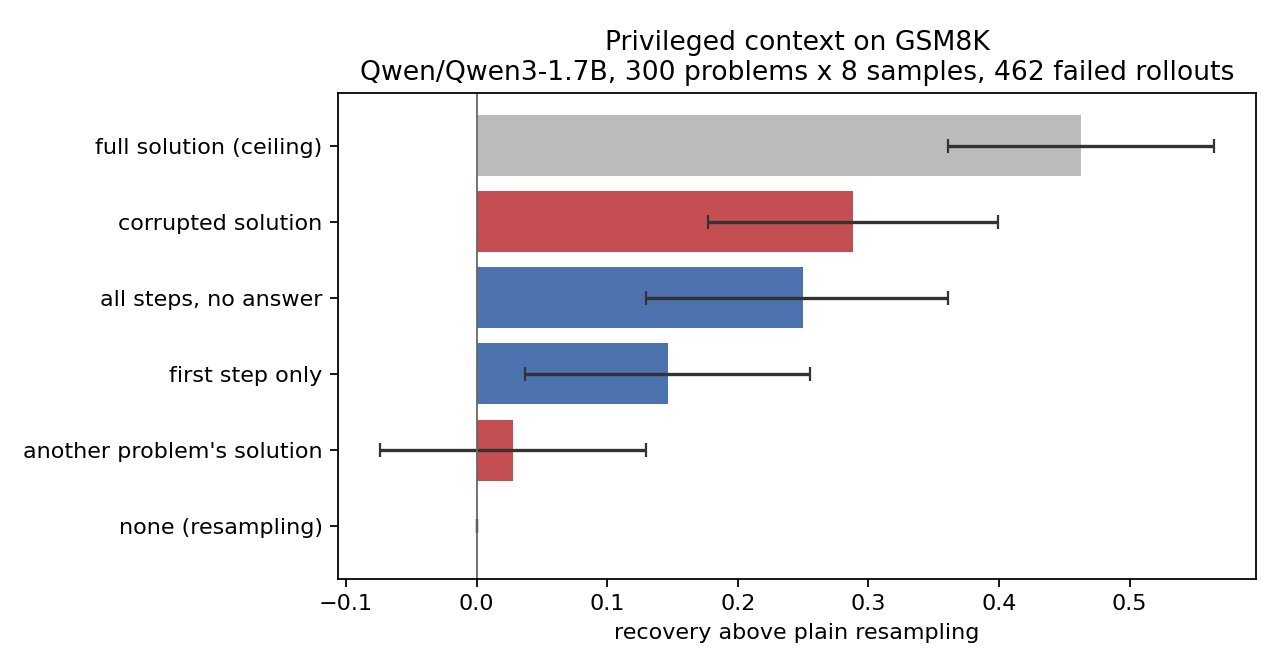

In [6]:
!python src/analyze.py --tag run
from IPython.display import Image
Image('figures/gaps.png')

In [7]:
# summary table
import json
import pandas as pd

WHAT = {
    "none": "nothing (plain resampling)",
    "gold_step1": "first reasoning step",
    "gold_steps": "all steps but the last",
    "gt_solution": "full solution, answer included",
    "wrong_solution": "another problem's solution",
    "corrupted_solution": "same solution, numbers shifted",
}

s = json.load(open("results/run_summary.json"))
df = pd.read_csv("results/gaps.csv")
df["what the teacher sees"] = df["condition"].map(WHAT)
df["95% CI"] = df.apply(lambda r: "[%+.3f, %+.3f]" % (r.ci_lo, r.ci_hi), axis=1)
out = df[["condition", "what the teacher sees", "recovery",
          "diff_vs_none", "95% CI", "follow_context"]]
out = out.rename(columns={"diff_vs_none": "vs none",
                          "follow_context": "copies the context"})
out = out.sort_values("vs none", ascending=False).reset_index(drop=True)

print("%s, %d problems x %d rollouts, student accuracy %.3f, %d failed rollouts\n" % (
    s["model"], s["n_problems"], s["n_samples"], s["student_acc"], s["n_failed"]))
display(out.round(3))
print("\nrecovery           share of the student's failed rollouts the self-teacher fixes")
print("vs none            the same number minus plain resampling, with a bootstrap CI")
print("copies the context how often the model returned the number the context points at")

Qwen/Qwen3-1.7B, 300 problems x 8 rollouts, student accuracy 0.807, 462 failed rollouts



,condition,what the teacher sees,recovery,vs none,95% CI,copies the context
0,gt_solution,"full solution, answer included",0.926,0.463,"[+0.361, +0.565]",0.000
1,corrupted_solution,"same solution, numbers shifted",0.751,0.288,"[+0.177, +0.400]",0.087
2,gold_steps,all steps but the last,0.713,0.250,"[+0.130, +0.361]",NaN
3,gold_step1,first reasoning step,0.610,0.147,"[+0.037, +0.255]",NaN
4,wrong_solution,another problem's solution,0.491,0.028,"[-0.074, +0.130]",0.000
5,none,nothing (plain resampling),0.463,0.000,"[+0.000, +0.000]",NaN



recovery           share of the student's failed rollouts the self-teacher fixes
vs none            the same number minus plain resampling, with a bootstrap CI
copies the context how often the model returned the number the context points at


## 6. Save the results back to the repo

Download, unzip locally, commit. Then `File -> Save a copy in GitHub` to push this
notebook with its outputs.

In [8]:
from google.colab import files
!zip -qr results.zip results figures data/contexts
files.download('results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>